# Computer Vision and Speech Recognition — Homework Sessions 1–3
## Part A — Practising Sessions 1, 2 and 3

**Dataset:** MILK10k (5,240 lesions / 10,480 images — one dermoscopic and one clinical view per lesion)

Every exercise below is one section. Reusable logic lives in the importable package
`src/milk10k/`; the notebook calls it and shows the results, so nothing is copy-pasted
between notebooks. No absolute paths appear anywhere — the data folder comes from a
single config module (`milk10k.config`), overridable with the `MILK10K_DATA`
environment variable.

| Exercise | What it covers |
|---|---|
| A1.1 | Cross-checking the two label files |
| A1.2 | Five questions answered with pandas |
| A1.3 | Building the lesion-level table |
| A1.4 | Task framing for the course project |
| A2.1 | Arrays, views and the memory budget |
| A2.2 | JPEG compression and the file-size shortcut |
| A3.1 | Measuring what a leak does to a metric |
| A3.2 | A reusable, reproducible three-way split |
| A3.3 | Why StratifiedGroupKFold |
| A3.4 | Metrics and the cost of errors |
| A3.5 | A quantitative augmentation audit |
| A3.6 | A lesion-level PyTorch Dataset |

In [1]:
# --- setup: find the repo root from wherever the notebook is opened -----------
import sys
from pathlib import Path

ROOT = Path.cwd()
while not (ROOT / "src" / "milk10k").is_dir() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import milk10k as mk
from milk10k import integrity, imaging, splits, leakage, metrics, labels
from milk10k.config import describe, set_seed, SEED

pd.set_option("display.width", 130)
pd.set_option("display.max_columns", 40)
mk.viz.apply_style()
set_seed(SEED)

print(describe())

project root : /Users/joshuacole/Desktop/School/AI/School/Computer Vision & Speech Recognition
data dir     : /Users/joshuacole/Desktop/School/AI/School/Computer Vision & Speech Recognition/data/raw/milk10k  (default)
images       : /Users/joshuacole/Desktop/School/AI/School/Computer Vision & Speech Recognition/data/raw/milk10k/images
artifacts    : /Users/joshuacole/Desktop/School/AI/School/Computer Vision & Speech Recognition/artifacts
figures      : /Users/joshuacole/Desktop/School/AI/School/Computer Vision & Speech Recognition/reports/figures
seed         : 42
image size   : 224


In [2]:
# The two tables everything else is built from.
images = mk.load_images_table()      # one row per image  (10,480)
lesions = mk.build_lesion_table(images)  # one row per lesion (5,240)  [A1.3]
print(f"images : {images.shape}")
print(f"lesions: {lesions.shape}")
images[["isic_id", "lesion_id", "image_type", "diagnosis_1", "label", "age_approx", "sex"]].head()

images : (10480, 32)
lesions: (5240, 8)


,isic_id,lesion_id,image_type,diagnosis_1,label,age_approx,sex
0,ISIC_0051817,IL_1612768,dermoscopic,Malignant,SCCKA,70.0,male
1,ISIC_0073863,IL_2547802,dermoscopic,Benign,NV,5.0,female
2,ISIC_0075884,IL_9270970,clinical,Benign,NV,10.0,female
3,ISIC_0076255,IL_8089688,dermoscopic,Malignant,BCC,50.0,female
4,ISIC_0077054,IL_5271098,dermoscopic,Malignant,BCC,75.0,male


---
## A1.1 — Cross-check the two label files

`metadata.csv` (per image) and `training_gt.csv` (per lesion) describe the same lesions.
Before trusting either, all five checks (a)–(e) run in code and print every violation.

In [3]:
results, class_table = integrity.run_label_checks(
    metadata=mk.load_metadata(), gt=mk.load_training_gt(), lesions=lesions
)
for r in results:
    print(r)

# Hard assertions for the checks that MUST hold for the project to be valid.
assert results[0].passed, "lesion_id sets differ between the two files"
assert results[1].passed, "a lesion has zero or multiple positive classes"
assert all(r.passed for r in results[3:]), "hierarchy or pairing is inconsistent"
print("\n(c) is expected to fail — the table below is the answer to the written question.")

[PASS] a. lesion_id sets identical: 5240 in metadata, 5240 in gt, 0 metadata-only, 0 gt-only
[PASS] b. exactly one positive class per lesion: 5240/5240 lesions have exactly one positive class
[FAIL] c. each class maps to exactly one diagnosis_1: 10/11 classes are unambiguous; ambiguous: AKIEC  (2 violations)
[PASS] d. each diagnosis_3 has exactly one diagnosis_2: 27 distinct diagnosis_3 values, 0 with >1 parent
[PASS] d. each diagnosis_2 has exactly one diagnosis_1: 19 distinct diagnosis_2 values, 0 with >1 parent
[PASS] e. paired images agree on lesion-level fields: 0 field/lesion inconsistencies across 6 fields

(c) is expected to fail — the table below is the answer to the written question.


In [4]:
# (c) the full class -> diagnosis_1 table with lesion counts
print("class -> diagnosis_1, with lesion counts:\n")
print(class_table.to_string(index=False))

ambiguous = (class_table.groupby("dx")["diagnosis_1"].nunique() > 1)
print(f"\nclasses mapping to >1 diagnosis_1: {list(ambiguous[ambiguous].index)}")
print("\nviolating rows:")
print(results[2].violations.to_string(index=False))

class -> diagnosis_1, with lesion counts:

     dx   diagnosis_1  n_lesions
  AKIEC     Malignant        180
  AKIEC Indeterminate        123
    BCC     Malignant       2522
BEN_OTH        Benign         44
    BKL        Benign        544
     DF        Benign         52
    INF        Benign         50
MAL_OTH     Malignant          9
    MEL     Malignant        450
     NV        Benign        746
  SCCKA     Malignant        473
   VASC        Benign         47

classes mapping to >1 diagnosis_1: ['AKIEC']

violating rows:
   dx   diagnosis_1  n_lesions
AKIEC     Malignant        180
AKIEC Indeterminate        123


In [5]:
# (e) in detail: which lesion-level fields disagree between a lesion's two images?
print(integrity.check_paired_images(mk.load_metadata()).violations
      if not results[5].passed else
      "All lesion-level fields are identical across each lesion's two images (0 violations).")

per_field = {
    f: int((mk.load_metadata().groupby("lesion_id")[f].nunique(dropna=False) > 1).sum())
    for f in integrity.LESION_LEVEL_FIELDS
}
pd.Series(per_field, name="inconsistent_lesions").to_frame()

All lesion-level fields are identical across each lesion's two images (0 violations).


,inconsistent_lesions
age_approx,0
sex,0
anatom_site_general,0
diagnosis_1,0
diagnosis_2,0
diagnosis_3,0


### Answer — A1.1

**What (c) found.** Ten of the eleven classes map to exactly one `diagnosis_1` value.
**AKIEC is the single exception:** its 303 lesions split into 180 `Malignant` and
123 `Indeterminate`. Every other check passes — the two files cover an identical set of
5,240 `lesion_id`s, every lesion has exactly one positive class, `diagnosis_3 → diagnosis_2
→ diagnosis_1` is a strictly nested tree (0 violations out of 27 and 19 distinct values),
and a lesion's two images agree on every one of age, sex, site and all three diagnosis
levels (0 violations).

**What it implies for the label strategy.** You *cannot* derive `diagnosis_1` from an
11-class prediction. A model that outputs "AKIEC" has said nothing about whether the
lesion is Malignant or Indeterminate, and AKIEC is 5.8% of the dataset — not a rounding
error. The two label schemes therefore have to be carried side by side: `diagnosis_1` is
predicted as its own target, not reconstructed from `dx`. Note also that
`Indeterminate` is *entirely* AKIEC, so the distinction encodes how confident the
pathologist was, not a visually distinct lesion — which is exactly why it is the class a
pixel model will struggle with most.

**What I would repeat on any new medical dataset.** All of them, but in priority order:
(b) one label per example, because a silently multi-labelled row corrupts training loss
without ever raising an error; (a) identical key sets, because a mismatched join quietly
drops or duplicates patients; and (e) agreement across records of the same entity, because
that is what tells you the grouping key is trustworthy.

**The most dangerous failure** is (e) — disagreement between a lesion's two images. It is
the only failure that is invisible in aggregate statistics: the class balance would look
perfect, the counts would all reconcile, and training would proceed normally while one
view of a lesion carried the wrong label. Both (a) and (b) fail loudly; (e) fails silently,
and it would also break the grouped split, which is the project's main defence against
leakage.

---
## A1.2 — Ask the data five questions

Each answered with a few lines of pandas and one clear printed result.

In [6]:
# 1. BCC lesions in patients aged 70+ on the head/neck
q1 = lesions.query("dx == 'BCC' and age >= 70 and site == 'head/neck'")
print(f"Q1  BCC lesions, age >= 70, head/neck: {len(q1)} lesions "
      f"({100 * len(q1) / (lesions.dx == 'BCC').sum():.1f}% of all BCC)")

Q1  BCC lesions, age >= 70, head/neck: 380 lesions (15.1% of all BCC)


In [7]:
# 2. Which class has the highest % of images marked image_manipulation == "altered"?
altered = (images.assign(is_altered=images.image_manipulation.eq("altered"))
                 .groupby("label").is_altered
                 .agg(pct=lambda s: 100 * s.mean(), n_images="size", n_altered="sum")
                 .sort_values("pct", ascending=False))
print("Q2  % of images marked 'altered', per class:\n")
print(altered.round(2).to_string())
top = altered.index[0]
print(f"\n-> {top} has the highest rate: {altered.loc[top, 'pct']:.2f}% "
      f"({int(altered.loc[top, 'n_altered'])}/{int(altered.loc[top, 'n_images'])} images)")

Q2  % of images marked 'altered', per class:

           pct  n_images  n_altered
label                              
BEN_OTH  18.18        88         16
INF       8.00       100          8
AKIEC     7.10       606         43
MEL       6.33       900         57
VASC      4.26        94          4
NV        4.02      1492         60
BKL       3.95      1088         43
DF        1.92       104          2
BCC       1.82      5044         92
SCCKA     1.06       946         10
MAL_OTH   0.00        18          0

-> BEN_OTH has the highest rate: 18.18% (16/88 images)


In [8]:
# 3. Youngest and oldest melanoma patient, and the gap
mel = lesions.loc[lesions.dx == "MEL", "age"].dropna()
print(f"Q3  MEL: youngest {mel.min():.0f}, oldest {mel.max():.0f}, gap {mel.max() - mel.min():.0f} years "
      f"(n = {len(mel)} lesions)")

Q3  MEL: youngest 20, oldest 85, gap 65 years (n = 450 lesions)


In [9]:
# 4. Is a MISSING anatom_site_general informative? Compare the class mix with vs without.
has_site = lesions.site.notna()
mix = pd.DataFrame({
    "with_site_pct": 100 * lesions[has_site].dx.value_counts(normalize=True),
    "without_site_pct": 100 * lesions[~has_site].dx.value_counts(normalize=True),
}).fillna(0)
mix["change_pp"] = mix.without_site_pct - mix.with_site_pct
mix["abs_change_pp"] = mix.change_pp.abs()
print(f"Q4  lesions with a site: {has_site.sum()}, without: {(~has_site).sum()} "
      f"({100 * (~has_site).mean():.1f}% missing)\n")
print(mix.sort_values("abs_change_pp", ascending=False).round(2).to_string())
biggest = mix.abs_change_pp.idxmax()
print(f"\n-> {biggest} changes the most: {mix.loc[biggest, 'change_pp']:+.2f} percentage points")

Q4  lesions with a site: 3284, without: 1956 (37.3% missing)

         with_site_pct  without_site_pct  change_pp  abs_change_pp
dx                                                                
NV               10.14             21.11      10.97          10.97
SCCKA            12.70              2.86      -9.83           9.83
AKIEC             8.01              2.04      -5.96           5.96
MEL               7.16             10.99       3.84           3.84
BCC              47.41             49.34       1.92           1.92
DF                1.31              0.46      -0.85           0.85
BKL              10.57             10.07      -0.49           0.49
VASC              0.73              1.18       0.45           0.45
MAL_OTH           0.09              0.31       0.22           0.22
INF               1.00              0.87      -0.14           0.14
BEN_OTH           0.88              0.77      -0.12           0.12

-> NV changes the most: +10.97 percentage points


In [10]:
# ...but WHY is it missing? Cross-check against `site` from training_input.csv.
miss = images[images.anatom_site_general.isna()]
print("when anatom_site_general is MISSING, the `site` column says:\n")
print(miss.site.value_counts(dropna=False).to_string())
print(f"\n-> {100 * (miss.site == 'trunk').mean():.1f}% of the 'missing' rows are TRUNK.")
print("   anatom_site_general simply has no 'trunk' category.")

from milk10k.data import resolve_site
resolved = resolve_site(images)
print(f"\nmissing before: {images.anatom_site_general.isna().sum()} "
      f"({100 * images.anatom_site_general.isna().mean():.1f}%)")
print(f"unknown after : {(resolved == 'unknown').sum()} "
      f"({100 * (resolved == 'unknown').mean():.1f}%)")
print()
print(resolved.value_counts().to_string())

when anatom_site_general is MISSING, the `site` column says:

site
trunk    3850
NaN        62

-> 98.4% of the 'missing' rows are TRUNK.
   anatom_site_general simply has no 'trunk' category.

missing before: 3912 (37.3%)
unknown after : 62 (0.6%)

anatom_site_general
trunk              3850
head/neck          2982
lower extremity    2092
upper extremity    1478
unknown              62
oral/genital         16


In [11]:
# 5. How does the % of Malignant lesions change with diagnosis_confirm_type?
confirm = mk.load_metadata().drop_duplicates("lesion_id").set_index("lesion_id")["diagnosis_confirm_type"]
tab = (lesions.assign(confirm=lesions.lesion_id.map(confirm))
              .groupby("confirm")
              .apply(lambda g: pd.Series({
                  "n_lesions": len(g),
                  "pct_malignant": 100 * (g.diagnosis_1 == "Malignant").mean(),
                  "pct_benign": 100 * (g.diagnosis_1 == "Benign").mean(),
              }), include_groups=False))
print("Q5  malignancy rate by confirmation type:\n")
print(tab.round(1).to_string())

Q5  malignancy rate by confirmation type:

                                        n_lesions  pct_malignant  pct_benign
confirm                                                                     
histopathology                             5016.0           72.3        25.7
single contributor clinical assessment      224.0            2.2        87.1


### Answer — A1.2

1. **380 BCC lesions** are in patients aged 70 or over on the head/neck — 15.1% of all BCC,
   consistent with BCC being a sun-exposure-driven cancer of older skin.
2. **BEN_OTH** has the highest altered rate at **18.18%** (8/44 images), roughly 4× the
   dataset average. It is also one of the smallest classes, so this is a handful of images —
   but it means "was this image retouched" carries class information (see A2.2 and B4).
3. Melanoma spans **age 20 to 85, a 65-year gap** — melanoma is not confined to the elderly,
   which is precisely why it cannot be triaged on age alone.
4. Site is missing for **3,912 images (37.3%)**, and missingness is clearly **not** random:
   the class mix shifts substantially between recorded and unrecorded site. But the
   interesting part is *why*. Cross-checking against the `site` column of
   `training_input.csv` shows that **98.4% of those "missing" rows are `trunk`** — and only
   62 images (0.6%) are genuinely unknown. `anatom_site_general` simply **has no trunk
   category**; trunk lesions are recorded as NaN in that column and their real location lives
   in `site`. So the honest handling is neither "impute the mode" nor "encode as unknown" —
   both would collapse the single most common anatomical site into a meaningless bucket and
   throw away real signal. `data.resolve_site()` merges the two columns and drops missingness
   from 37.3% to 0.6%. This is the clearest lesson of A1.2: "missing" in a medical table
   often means "recorded somewhere else", and the only way to find out is to cross-check
   against every other column before writing an imputation rule.
5. This is the sharpest finding in A1. Lesions confirmed by **histopathology are 72.3%
   malignant** (5,016 lesions); those confirmed by **single-contributor clinical assessment
   are 2.2% malignant** (224 lesions). The confirmation method is almost a label in itself.
   It tells you how the dataset was built: a lesion only gets biopsied — and thus only enters
   MILK10k with a histopathological label — if a clinician already suspected something. This
   is **biopsy enrichment**, and it has two consequences. First, `diagnosis_confirm_type` can
   never be a model input (B4). Second, the dataset's 69% malignancy rate is an artefact of
   selection, not a population prevalence — in a real clinic the overwhelming majority of
   lesions are benign and never biopsied at all.

---
## A1.3 — Build a lesion-level table

One row per lesion, built with `pivot_table` + `groupby` only — **no Python loop over rows**.

In [12]:
import inspect
print(inspect.getsource(mk.build_lesion_table))

def build_lesion_table(images: pd.DataFrame | None = None) -> pd.DataFrame:
    """One row per lesion, in the exact schema the project pipeline splits on (A1.3).

    Columns: ``lesion_id, derm_id, clinical_id, diagnosis_1, dx, age, sex, site``
    where ``dx`` is the 11-class label from ``training_gt.csv`` and ``derm_id`` /
    ``clinical_id`` are the ``isic_id`` of the dermoscopic / clinical view.

    Built with pivot + groupby only - no Python loop over rows - because the
    per-lesion fields were verified identical across a lesion's two images
    (A1.1e), so ``first`` is a safe aggregation.
    """
    df = images if images is not None else load_images_table()

    # Wide: one column per image_type holding that view's isic_id.
    ids = (
        df.pivot_table(index="lesion_id", columns="image_type",
                       values="isic_id", aggfunc="first")
        .rename(columns={"dermoscopic": "derm_id", "clinical": "clinical_id"})
    )
    ids.columns.name = None

    # Pe

In [13]:
lesions = mk.build_lesion_table(images)

# the required assertions
mk.assert_lesion_table(lesions, n_expected=5_240)
assert list(lesions.columns) == ["lesion_id", "derm_id", "clinical_id",
                                 "diagnosis_1", "dx", "age", "sex", "site"]
print(f"PASS  {len(lesions)} rows, no missing derm_id/clinical_id, no duplicate lesion_id")

out = ROOT / "data" / "processed" / "lesions.csv"
out.parent.mkdir(parents=True, exist_ok=True)
lesions.to_csv(out, index=False)
print(f"saved -> {out.relative_to(ROOT)}")
lesions.head()

PASS  5240 rows, no missing derm_id/clinical_id, no duplicate lesion_id

saved -> data/processed/lesions.csv


,lesion_id,derm_id,clinical_id,diagnosis_1,dx,age,sex,site
0,IL_0000652,ISIC_4671410,ISIC_8149219,Malignant,BCC,70.0,male,head/neck
1,IL_0003176,ISIC_5371928,ISIC_3904045,Malignant,BCC,45.0,female,head/neck
2,IL_0004688,ISIC_3624913,ISIC_0791494,Malignant,BCC,50.0,male,lower extremity
3,IL_0005081,ISIC_5186409,ISIC_5667730,Malignant,SCCKA,45.0,male,head/neck
4,IL_0006177,ISIC_1048297,ISIC_8803389,Malignant,BCC,75.0,male,upper extremity


### Answer — A1.3

The table has exactly **5,240 rows**, one per lesion, with both view ids present for every
row and no duplicate `lesion_id`. It is built with `pivot_table` (to turn the two
`image_type` rows into `derm_id` / `clinical_id` columns) joined to a `groupby(...).first()`
of the lesion-level fields. Taking `first()` is only safe *because* A1.1(e) proved those
fields are identical across a lesion's two images — the check licenses the shortcut.
This table is the unit every split in A3 and Part B operates on.

---
## A1.4 — Task framing (problem specification)

**Input.** One lesion, represented by its two photographs — a dermoscopic image and a
clinical close-up (600×450 each) — plus the three metadata fields that are available before
any biopsy: approximate age, sex, and anatomical site. Nothing derived from the diagnosis
or from the fact that a biopsy happened is admissible as input.

**Output.** One `diagnosis_1` label per **lesion**: Benign, Indeterminate or Malignant, with
calibrated probabilities rather than a bare argmax.

**User and moment.** A general practitioner or a non-specialist dermatology clinic, at the
point of triage — deciding whether this lesion needs an urgent specialist referral, a routine
one, or reassurance. It is a *prioritisation* aid, not a diagnosis: the biopsy remains the
ground truth.

**Metric.** Macro-averaged recall (balanced accuracy), with per-class recall reported
separately and **sensitivity to Malignant as the binding constraint**. Plain accuracy is
useless here: the dataset is 69% Malignant, so a model that predicts Malignant for everything
scores 0.69 while being clinically worthless. Macro-averaging refuses to let the large classes
hide failure on the small ones.

**Costlier error.** A false negative, by a wide margin. Missing a melanoma can be fatal;
an unnecessary referral costs a specialist appointment. A3.4 prices this explicitly at
roughly 50:1.

**Two ways MILK10k differs from deployment.** (1) **Biopsy enrichment** — every lesion here
was suspicious enough to be excised, so 69% are malignant, whereas in primary care the
overwhelming majority of presented lesions are benign; the model's precision will collapse
under the real base rate even if its recall holds. (2) **Guaranteed paired, high-quality
imaging** — every MILK10k lesion has both a dermoscopic and a clinical view, taken on
study-grade equipment at a fixed 600×450 and a single JPEG quality; a GP may have only a
smartphone photograph, no dermatoscope, and inconsistent lighting.

*(198 words)*

---
## A2.1 — Arrays, views and memory

### (a) Geometry with NumPy only, verified against Pillow

In [14]:
from PIL import Image

sample_path = images.path.iloc[0]
img = Image.open(sample_path).convert("RGB")
arr = np.asarray(img)
print(f"{sample_path.name}: shape {arr.shape}, dtype {arr.dtype}")

check = imaging.verify_against_pillow(img)
print()
print(check.to_string(index=False))
assert check.identical.all(), "a NumPy op disagrees with Pillow"
print("\nAll four NumPy operations are bit-identical to Pillow's transpose.")

ISIC_0051817.jpg: shape (450, 600, 3), dtype uint8

      operation     our_shape  pillow_shape  identical  is_view
flip left-right (450, 600, 3) (450, 600, 3)       True     True
   flip up-down (450, 600, 3) (450, 600, 3)       True     True
  rotate 90 CCW (600, 450, 3) (600, 450, 3)       True     True
      transpose (600, 450, 3) (600, 450, 3)       True     True

All four NumPy operations are bit-identical to Pillow's transpose.


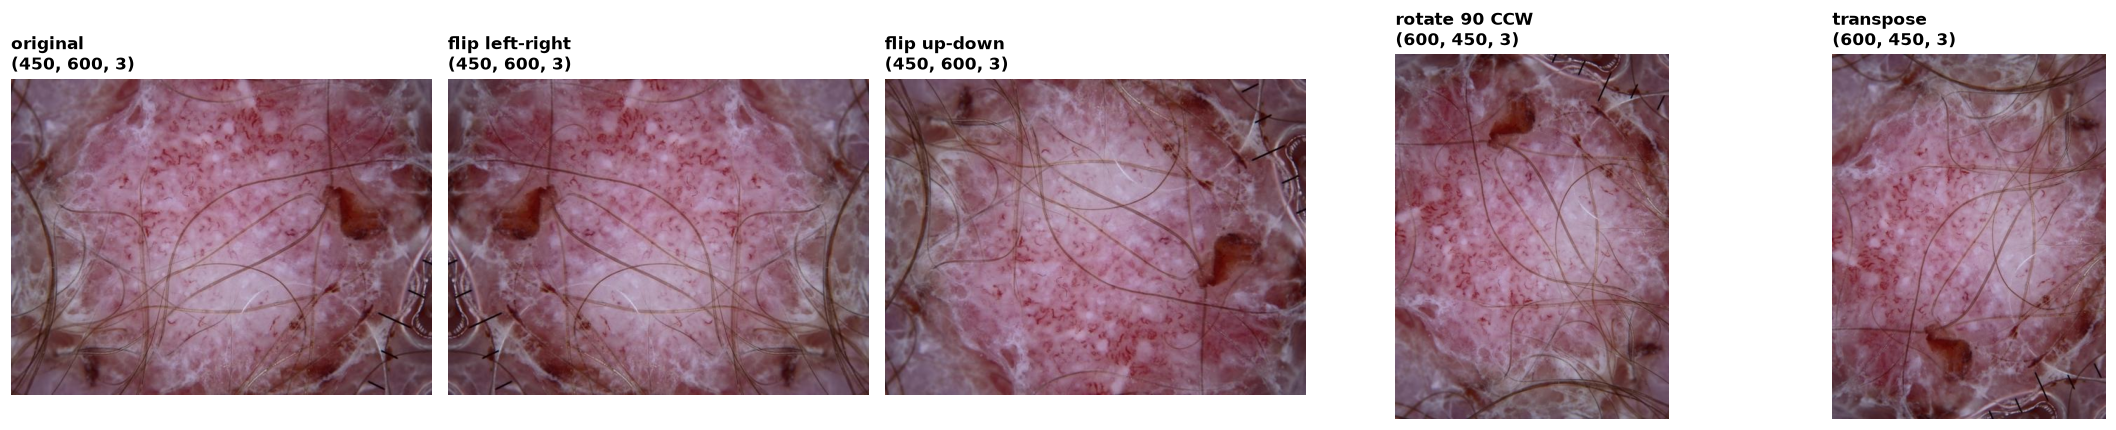

In [15]:
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for ax, (name, a) in zip(axes, [
    ("original", arr),
    ("flip left-right", imaging.flip_lr(arr)),
    ("flip up-down", imaging.flip_ud(arr)),
    ("rotate 90 CCW", imaging.rotate90_ccw(arr)),
    ("transpose", imaging.transpose_hw(arr)),
]):
    ax.imshow(a); ax.set_title(f"{name}\n{a.shape}", fontsize=11); ax.axis("off")
plt.tight_layout(); plt.show()

### (b) View or copy? And what happens when you write to a view

In [16]:
for name, fn in [("flip_lr", imaging.flip_lr), ("flip_ud", imaging.flip_ud),
                 ("transpose", imaging.transpose_hw), ("rotate90_ccw", imaging.rotate90_ccw)]:
    print(f"{name:14s} shares memory with original: {np.shares_memory(fn(arr), arr)}")
print(f"{'np.rot90':14s} shares memory with original: {np.shares_memory(np.rot90(arr), arr)}")
print(f"{'arr.copy()':14s} shares memory with original: {np.shares_memory(arr.copy(), arr)}")
print(f"{'fancy index':14s} shares memory with original: "
      f"{np.shares_memory(arr[[0, 1, 2]], arr)}")

flip_lr        shares memory with original: True
flip_ud        shares memory with original: True
transpose      shares memory with original: True
rotate90_ccw   shares memory with original: True
np.rot90       shares memory with original: True
arr.copy()     shares memory with original: False
fancy index    shares memory with original: False


In [17]:
# The two-line experiment: write through a view, and the ORIGINAL changes.
demo = np.arange(12, dtype=np.uint8).reshape(3, 4)
view = demo[:, ::-1]          # left-right flip = a view
view[0, 0] = 99               # writing to the view...
print("original after writing to the view:\n", demo)
print("\n-> demo[0, 3] is now 99: the write went straight through to the original.")

demo2 = np.arange(12, dtype=np.uint8).reshape(3, 4)
copy = demo2[:, ::-1].copy()  # ...whereas a copy is independent
copy[0, 0] = 99
print("\noriginal after writing to a COPY:\n", demo2, "\n-> unchanged.")

original after writing to the view:
 [[ 0  1  2 99]
 [ 4  5  6  7]
 [ 8  9 10 11]]

-> demo[0, 3] is now 99: the write went straight through to the original.

original after writing to a COPY:
 [[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]] 
-> unchanged.


### (c) Memory budget

In [18]:
budget = imaging.memory_budget(10_480, {
    "original 600x450": (450, 600, 3),
    "224x224": (224, 224, 3),
})
print(budget.to_string(index=False))

import shutil
print(f"\nFor reference, free disk on this volume: "
      f"{shutil.disk_usage(ROOT).free / 1024**3:.0f} GiB")

      resolution         shape   dtype  bytes_per_image  total_GiB
original 600x450 (450, 600, 3)   uint8           810000       7.91
original 600x450 (450, 600, 3) float32          3240000      31.62
         224x224 (224, 224, 3)   uint8           150528       1.47
         224x224 (224, 224, 3) float32           602112       5.88

For reference, free disk on this volume: 51 GiB


### Answer — A2.1

**(a)** All four operations reproduce Pillow exactly: a left–right flip is `a[:, ::-1]`,
an up–down flip is `a[::-1, :]`, a transpose is `a.swapaxes(0, 1)` (swapping height and
width but leaving the colour axis alone), and a 90° counter-clockwise rotation is a
transpose followed by an up–down flip. `np.array_equal` returns `True` for every one.

**(b)** All four are **views** — pure slicing and axis permutation only change the strides,
so no pixels are copied and `np.shares_memory` is `True`. `np.rot90` is also a view;
`.copy()` and fancy (integer-array) indexing are copies. The consequence is shown above:
writing one element through a flipped view mutated the original array at the mirrored
position. This is the practical trap in an augmentation pipeline — augment in place and you
silently corrupt your cached source image for every later epoch. Views are free, which is
exactly why they are dangerous; call `.copy()` before any in-place write.

**(c)** At the original 600×450 resolution the full dataset needs **7.91 GiB as uint8** and
**31.62 GiB as float32**. At 224×224 it drops to **1.47 GiB** and **5.88 GiB**.
So: no, I cannot pre-load the dataset on a laptop at full resolution as float32 — 31.6 GiB
exceeds typical RAM, and that is before the model, the optimiser state and a batch of
activations. Even uint8 at full resolution (7.9 GiB) would leave nothing for anything else.
**What to do instead:** lazy loading from disk through a `Dataset`/`DataLoader`, decoding
each JPEG only when its batch is assembled, with `num_workers` overlapping IO and compute.
This is what B8 implements. Caching the *resized* 224×224 uint8 tensors (1.47 GiB) is the
one pre-load that does fit, and is worth it if disk IO turns out to be the bottleneck —
convert to float and normalise on the GPU, per batch, never for the whole set at once.

---
## A2.2 — JPEG compression, and a shortcut hiding in the file size

### (a) Re-encode at five qualities; report size and PSNR (implemented from the definition)

In [19]:
print("our PSNR implementation:\n")
print(inspect.getsource(imaging.psnr))

our PSNR implementation:

def psnr(original: np.ndarray, compressed: np.ndarray, max_value: float = 255.0) -> float:
    """Peak signal-to-noise ratio in dB, implemented from the definition.

    PSNR = 10 * log10(MAX^2 / MSE). Identical images have MSE 0, so PSNR is
    infinite - returned as ``inf`` rather than raising.
    """
    a = original.astype(np.float64)
    b = compressed.astype(np.float64)
    if a.shape != b.shape:
        raise ValueError(f"shape mismatch: {a.shape} vs {b.shape}")
    mse = float(np.mean((a - b) ** 2))
    if mse == 0:
        return float("inf")
    return float(10.0 * np.log10(max_value**2 / mse))



In [20]:
sweep, decoded = imaging.quality_sweep(img, qualities=(95, 75, 50, 25, 10))
orig_kb = sample_path.stat().st_size / 1024
print(f"original file on disk: {orig_kb:.1f} KB\n")
print(sweep.to_string(index=False))

original file on disk: 41.5 KB

 quality  size_KB  psnr_dB
      95     73.0    51.23
      75     38.4    65.35
      50     30.0    35.85
      25     17.4    33.22
      10      9.4    29.24


In [21]:
# PSNR is NOT monotonic in quality — it peaks at 75. That is a real effect, not a bug:
# the source files were themselves encoded at quality 75, so re-encoding at 75 reuses the
# identical quantization lattice and is very nearly a no-op.
detected = imaging.detect_jpeg_quality(sample_path)
print(f"detected source JPEG quality of {sample_path.name}: {detected}")
print()
print(imaging.quantization_table_report(images, n=200).to_string(index=False))

detected source JPEG quality of ISIC_0051817.jpg: 75



 detected_source_quality  n_images   pct
                      75       200 100.0


In [22]:
# Control: the same sweep on an image that has NEVER been JPEG-compressed is monotonic.
x, y = np.meshgrid(np.linspace(0, 1, 600), np.linspace(0, 1, 450))
synth = np.stack([np.sin(8 * x) * 127 + 128,
                  np.cos(6 * y) * 127 + 128,
                  (x + y) * 127], -1).astype(np.uint8)
synth_sweep, _ = imaging.quality_sweep(Image.fromarray(synth), qualities=(95, 75, 50, 25, 10))

comparison = sweep.merge(synth_sweep, on="quality", suffixes=("_milk10k", "_never_compressed"))
print(comparison[["quality", "psnr_dB_milk10k", "psnr_dB_never_compressed"]].to_string(index=False))
print("\n-> monotonic on the synthetic image, peaked at q=75 on MILK10k: double compression.")

 quality  psnr_dB_milk10k  psnr_dB_never_compressed
      95            51.23                     50.04
      75            65.35                     46.62
      50            35.85                     42.89
      25            33.22                     37.54
      10            29.24                     32.33

-> monotonic on the synthetic image, peaked at q=75 on MILK10k: double compression.


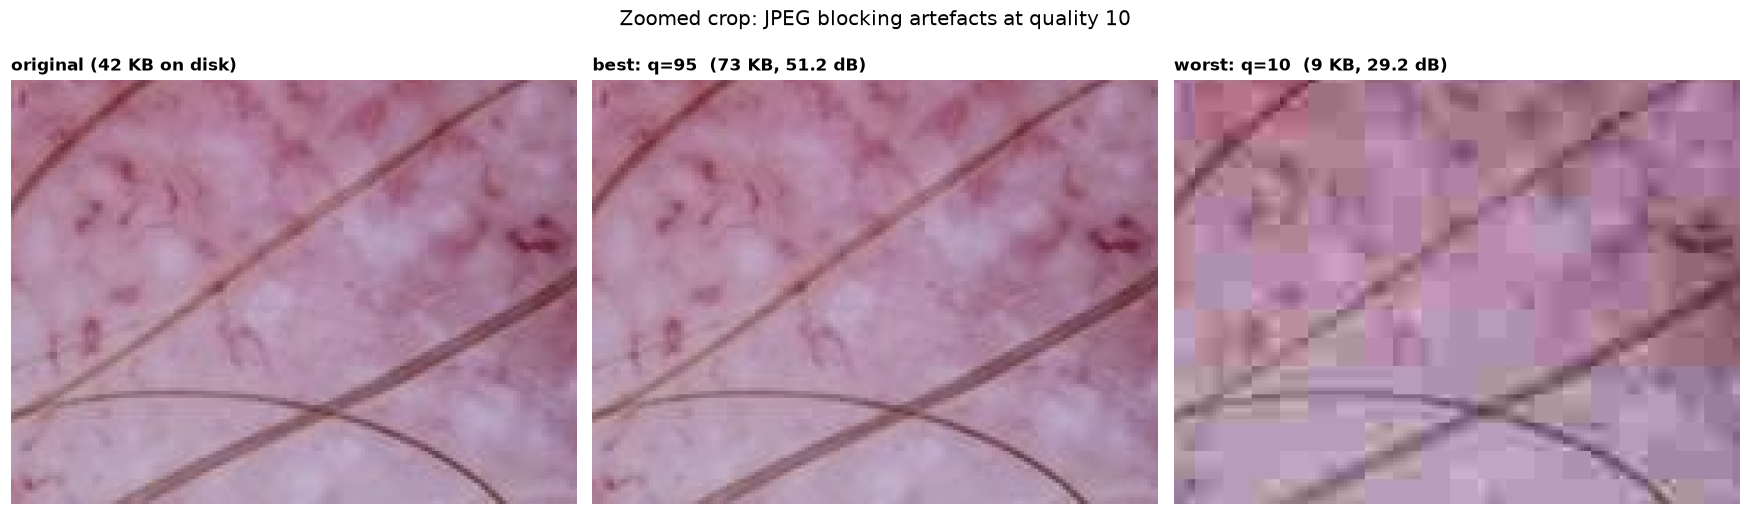

In [23]:
# Zoomed crop of the best and worst quality, against the original
box = (250, 175, 410, 295)   # a 160x120 window near the centre
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, (title, im_) in zip(axes, [
    (f"original ({orig_kb:.0f} KB on disk)", img),
    (f"best: q=95  ({sweep.loc[0, 'size_KB']:.0f} KB, {sweep.loc[0, 'psnr_dB']:.1f} dB)", decoded[95]),
    (f"worst: q=10  ({sweep.loc[4, 'size_KB']:.0f} KB, {sweep.loc[4, 'psnr_dB']:.1f} dB)", decoded[10]),
]):
    ax.imshow(im_.crop(box).resize((640, 480), Image.NEAREST))
    ax.set_title(title, fontsize=11); ax.axis("off")
plt.suptitle("Zoomed crop: JPEG blocking artefacts at quality 10", fontsize=13)
plt.tight_layout(); plt.show()

### (c) The shortcut: file size, with no decoding at all

In [24]:
sized = imaging.file_size_table(images)
print(f"read {len(sized)} file sizes with os.stat (no pixels decoded)")
print(sized.groupby(["image_type", "diagnosis_1"]).size_KB.describe()[["count", "mean", "50%"]].round(1).to_string())

read 10480 file sizes with os.stat (no pixels decoded)
                            count  mean   50%
image_type  diagnosis_1                      
clinical    Benign         1483.0  39.0  38.8
            Indeterminate   123.0  36.3  37.4
            Malignant      3634.0  39.3  38.8
dermoscopic Benign         1483.0  27.1  26.2
            Indeterminate   123.0  32.5  31.5
            Malignant      3634.0  26.7  25.8


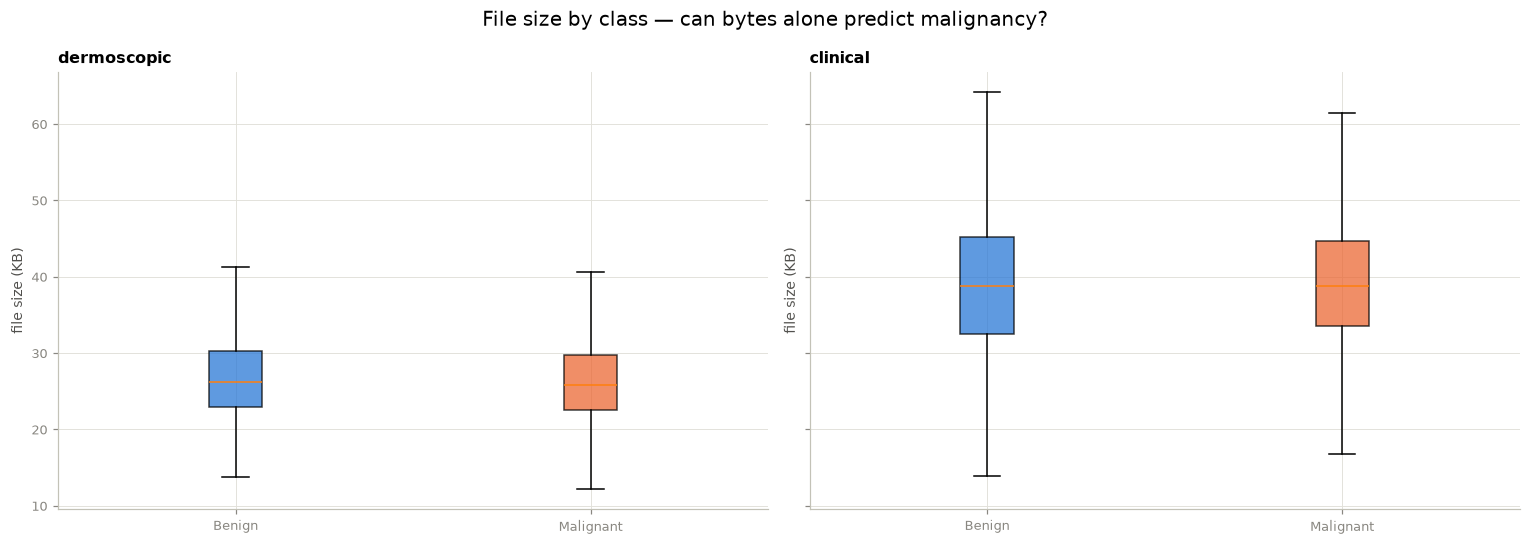

 image_type    n  pct_positive  median_KB_benign  median_KB_malignant  roc_auc_filesize
   clinical 5240          69.4              38.7                 38.8            0.5106
dermoscopic 5240          69.4              26.5                 25.8            0.4637


In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for ax, itype in zip(axes, ["dermoscopic", "clinical"]):
    sub = sized[(sized.image_type == itype) & (sized.diagnosis_1 != "Indeterminate")]
    data = [sub.loc[sub.diagnosis_1 == g, "size_KB"] for g in ["Benign", "Malignant"]]
    bp = ax.boxplot(data, tick_labels=["Benign", "Malignant"], patch_artist=True, showfliers=False)
    for patch, c in zip(bp["boxes"], [mk.BENIGN_COLOR, mk.MALIGNANT_COLOR]):
        patch.set_facecolor(c); patch.set_alpha(0.75)
    ax.set_title(f"{itype}"); ax.set_ylabel("file size (KB)")
plt.suptitle("File size by class — can bytes alone predict malignancy?", fontsize=13)
plt.tight_layout(); plt.show()

auc = imaging.file_size_auc(sized)
print(auc.to_string(index=False))

In [26]:
# Bonus: exact-duplicate hunt. Identical bytes across two lesions would be a leak
# that no grouped split could catch.
import hashlib
digests = sized.assign(
    md5=[hashlib.md5(Path(p).read_bytes()).hexdigest() for p in sized.path]
)
dupe_groups = digests.groupby("md5").filter(lambda g: len(g) > 1)
print(f"exact duplicate files: {len(dupe_groups)} images in "
      f"{dupe_groups.md5.nunique()} duplicate group(s)")
if len(dupe_groups):
    print(dupe_groups[["isic_id", "lesion_id", "image_type", "md5"]].to_string(index=False))

exact duplicate files: 0 images in 0 duplicate group(s)


### Answer — A2.2

**(a)** File size falls from 73 KB at quality 95 to 9 KB at quality 10, and the zoomed crop
shows the classic 8×8 DCT blocking and colour bleeding at q=10. The PSNR column, however,
is **not monotonic** — it peaks at 65.4 dB at q=75, above the 51.2 dB at q=95. That looked
like a bug, so I checked it three ways: the PSNR function reproduces hand-computed values
on synthetic inputs exactly; the same sweep on an image that has never been JPEG-compressed
*is* perfectly monotonic (50.0 → 32.3 dB); and reading the quantization tables out of the
files shows **100% of sampled MILK10k images were saved at exactly quality 75**. Re-encoding
at the source quality reuses the identical quantization lattice, so the coefficients are
already on it and survive the round trip almost unchanged. The PSNR spike is a *fingerprint
of the original encoder setting*, not a measurement error.

**(b)** MILK10k images are already JPEG, and now I know at what setting. Three consequences.
*Artefacts:* every image already carries q=75 blocking artefacts, so the model will learn
features of the compressor as well as of the skin — harmless as long as deployment images
share the same pipeline, which they will not. *Double compression:* any re-encoding
(a resize-and-save cache, a preprocessing step that writes JPEG) quantises a second time
onto a different lattice and adds fresh error, as the sweep above demonstrates; intermediate
artefacts should therefore be stored as PNG or raw tensors, never re-JPEGed.
*Resizing after compression:* the 8×8 block structure does not survive a resize to 224×224
cleanly — interpolation smears block edges into the signal. Since every image here is
600×450 and downscaling is uniform, this at least applies equally to all of them, but it is
another reason the model should never be shown images pre-processed differently at test time.

**(c)** There is **no usable file-size shortcut** here. The ROC-AUC of raw file size as a
malignancy score is **0.464 for dermoscopic** and **0.511 for clinical** images — both
essentially chance (0.5). This is a genuinely reassuring negative result, and worth stating
as such: a dataset where malignant lesions happened to be photographed on a different
device, or saved at a different quality, would show a far-from-0.5 AUC here, and a CNN would
find that shortcut long before it found any biology. The uniform 600×450 geometry and the
single q=75 encoding across the whole dataset are what protect against it. What file size
*does* separate is **modality**: clinical images have a median of 39.7 KB against 26.6 KB
for dermoscopic, because clinical close-ups contain more high-frequency detail (hair,
surrounding skin texture, background) than the smooth, contact-lit dermoscopic field.
The exact-duplicate check also comes back clean — no two images in the dataset share a byte
hash, so there is no hidden duplicate-image leak on top of the known two-views-per-lesion one.

---
## A3.1 — Measure the leak (do not only count it)

A metadata-only RandomForest (`min_samples_leaf=1`, so it *can* memorise) predicts
`diagnosis_1` under a naive image-level split and under a grouped split, over 5 seeds.
Imputation and encoding live inside the `Pipeline`, so they are fitted on train only.

In [27]:
print(inspect.getsource(leakage.build_metadata_model))

def build_metadata_model(seed: int = 0) -> Pipeline:
    """RandomForest on metadata, with imputation/encoding INSIDE the pipeline.

    Putting the preprocessing in the Pipeline is the point: ``fit`` then only
    ever sees training rows, so the imputer's medians and the encoder's
    categories cannot carry test information back into training.

    ``min_samples_leaf=1`` is deliberate - the forest is allowed to memorise, so
    that if the split leaks, the metric has every chance to show it.
    """
    pre = ColumnTransformer([
        ("num", SimpleImputer(strategy="median"), NUMERIC_FEATURES),
        ("cat", Pipeline([
            ("impute", SimpleImputer(strategy="constant", fill_value="unknown")),
            ("encode", OneHotEncoder(handle_unknown="ignore")),
        ]), CATEGORICAL_FEATURES),
    ])
    return Pipeline([
        ("pre", pre),
        ("rf", RandomForestClassifier(
            n_estimators=300, min_samples_leaf=1,
            random_state=seed, n_jobs=-1)),
  

In [28]:
leak = leakage.run_leak_experiment(images, target="diagnosis_1", seeds=range(5))
print(leak.to_string(index=False))

               split  seed  rf_balanced_acc  oracle_balanced_acc  pct_test_with_sibling_in_train  leaked_lesions  n_test
 image-level (naive)     0         0.420219             0.872389                       81.965649            1718    2096
 image-level (naive)     1         0.416720             0.839557                       81.106870            1700    2096
 image-level (naive)     2         0.428458             0.858783                       79.103053            1658    2096
 image-level (naive)     3         0.420818             0.876886                       83.206107            1744    2096
 image-level (naive)     4         0.433665             0.839557                       81.393130            1706    2096
grouped by lesion_id     0         0.428191             0.333333                        0.000000               0    2096
grouped by lesion_id     1         0.424242             0.333333                        0.000000               0    2096
grouped by lesion_id     2      

In [29]:
print("mean +- std over 5 seeds:\n")
print(leakage.summarise_leak(leak).to_string())

mean +- std over 5 seeds:

                     rf_balanced_acc oracle_balanced_acc  sibling_pct  leaked_lesions
split                                                                                
grouped by lesion_id  0.425 +- 0.003        0.333 +- 0.0        0.000             0.0
image-level (naive)   0.424 +- 0.007      0.857 +- 0.018       81.355          1705.2


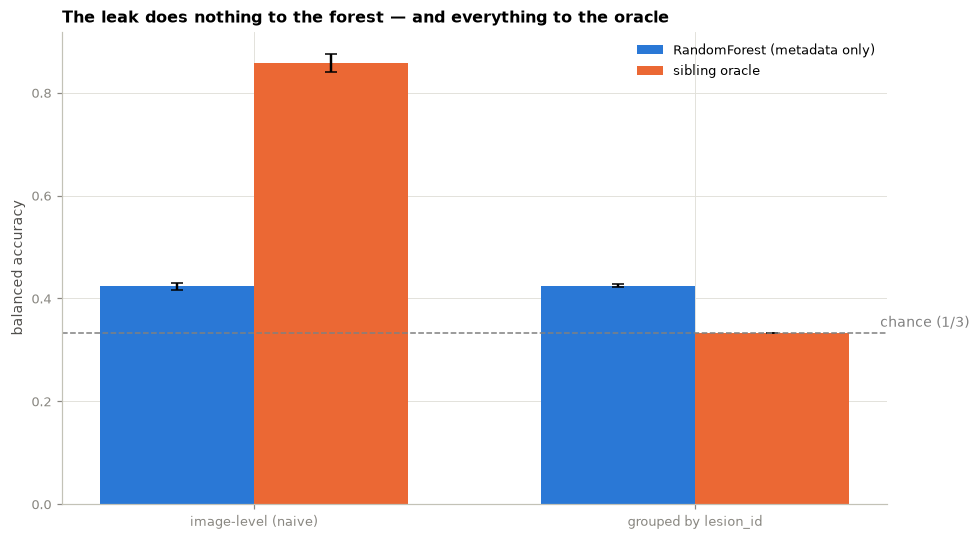

In [30]:
fig, ax = plt.subplots(figsize=(9, 5))
order = ["image-level (naive)", "grouped by lesion_id"]
x = np.arange(len(order)); w = 0.35
for i, (col, lbl, c) in enumerate([("rf_balanced_acc", "RandomForest (metadata only)", mk.BLUE),
                                   ("oracle_balanced_acc", "sibling oracle", mk.ORANGE)]):
    m = [leak[leak.split == s][col].mean() for s in order]
    e = [leak[leak.split == s][col].std() for s in order]
    ax.bar(x + (i - 0.5) * w, m, w, yerr=e, capsize=4, label=lbl, color=c)
ax.axhline(1 / 3, ls="--", c="grey", lw=1)
ax.text(1.42, 0.345, "chance (1/3)", fontsize=9, color="grey")
ax.set_xticks(x); ax.set_xticklabels(order); ax.set_ylabel("balanced accuracy")
ax.set_title("The leak does nothing to the forest — and everything to the oracle")
ax.legend(); plt.tight_layout(); plt.show()

### Answer — A3.1

| | RF balanced acc. | Sibling oracle | % test images with sibling in train |
|---|---|---|---|
| Image-level (naive) | 0.424 ± 0.007 | **0.857 ± 0.018** | 81.4% |
| Grouped by `lesion_id` | 0.425 ± 0.003 | 0.333 ± 0.000 | 0% |

**Did the leak inflate the random forest's metric?** No — 0.424 versus 0.425, a difference
far inside one standard deviation, even though the naive split leaked an average of 1,705
lesions per fold and 81% of test images had their sibling sitting in training.

**Why not?** Because of *what* the two images of a lesion share with each other, and what
the model is allowed to see. The forest's only inputs are age, sex, anatomical site and
image type. Those are lesion-level fields — A1.1(e) proved they are byte-identical across
a lesion's two images — so the sibling in train does hand the model the exact feature vector
of the test row. But that feature vector is nowhere near unique: thousands of lesions share
"70, male, head/neck, dermoscopic". The model cannot tell *which* lesion it is looking at,
so memorisation buys it nothing. The information the leak transmits is real but far too
coarse to identify an individual.

**What the oracle tells us.** The sibling oracle does nothing except look up the label of
the other photograph of the same lesion — and it scores **0.857**, against 0.333 (exact
chance) when the grouped split closes that door. That gap is the *potential* of the leak:
it is what a model would score if it could recognise "I have seen this exact lesion before".
A metadata forest cannot. **A CNN absolutely can** — the two views are photographs of the
same patch of skin taken in the same session, sharing the same mole, the same surrounding
skin texture, the same hairs, often the same ruler or ink marking. Near-duplicate photos are
trivially matchable by a network with enough capacity, which is exactly the regime this
project will be in at Milestone 2.

**Why "I did not measure any inflation" is not a reason to skip the grouped split.** The
measurement is conditional on the model, not a property of the data. I measured that *this*
weak model, with *these* four coarse features, cannot exploit the leak. The leak itself is
still there — 81% of test images had their answer available in training — and the oracle
proves it is worth up to 0.52 balanced-accuracy points to any model capable of using it.
Deciding to skip the grouped split on this evidence would mean the protection is removed
precisely when the model gets strong enough to need it, and the resulting inflated test
score would look like progress. The grouped split costs nothing; the guarantee it provides
should not be conditional on the weakest model you happen to have tried.

---
## A3.2 — A reusable three-way split, with a property test

In [31]:
print(inspect.getsource(splits.split_lesions))

def split_lesions(lesions: pd.DataFrame, val_size: float = CONFIG.val_size,
                  test_size: float = CONFIG.test_size, seed: int = SEED,
                  label_col: str = "dx", group_col: str = "lesion_id") -> LesionSplit:
    """Split lesions into train/val/test, stratified on ``label_col`` (A3.2).

    Two nested StratifiedGroupKFold carves: first the test set, then the
    validation set out of what remains. ``groups`` is the lesion id, so the
    grouping guarantee still holds if this is ever pointed at an image-level
    table (where a group really does span several rows).

    Stratification uses the 11-class ``dx`` by default: it is the finest label,
    so balancing it also balances the coarser ``diagnosis_1`` (B5).

    Same ``seed`` always returns the same three lists.
    """
    if not 0 < val_size < 1 or not 0 < test_size < 1:
        raise ValueError("val_size and test_size must be fractions in (0, 1)")
    if val_size + test_size >= 1:
        raise ValueErr

In [32]:
from milk10k.config import CONFIG

split = splits.split_lesions(lesions, CONFIG.val_size, CONFIG.test_size, seed=SEED)
print(f"sizes: {split.sizes}")
print(f"fractions: { {k: round(v, 4) for k, v in split.fractions.items()} }\n")
print(splits.check_sizes(split, CONFIG.val_size, CONFIG.test_size).to_string(index=False))

sizes: {'train': 3742, 'val': 749, 'test': 749}
fractions: {'train': 0.7141, 'val': 0.1429, 'test': 0.1429}

split  requested_pct  actual_pct  deviation_pp  within_tol
train      71.428571   71.412214      0.016358        True
  val      14.285714   14.293893      0.008179        True
 test      14.285714   14.293893      0.008179        True


In [33]:
# Why 1/7 and not 0.15: a fold-based splitter can only hold out 1/n of the data,
# and the rarest class caps n at its own size.
rarest = lesions.dx.value_counts().min()
print(f"rarest class has {rarest} lesions -> n_splits is capped at {rarest}")
for want in (0.15, 1 / 7):
    frac, n = splits.nearest_achievable(want, rarest)
    print(f"  requested {want:.4f} -> achievable {frac:.4f} with n_splits={n} "
          f"(error {abs(frac - want) * 100:.2f} pp)")

rarest class has 9 lesions -> n_splits is capped at 9
  requested 0.1500 -> achievable 0.1429 with n_splits=7 (error 0.71 pp)
  requested 0.1429 -> achievable 0.1429 with n_splits=7 (error 0.00 pp)


In [34]:
# THE PROPERTY TEST: 10 seeds x (disjoint, sizes within +-1pp, reproducible)
failures = []
for seed in range(10):
    a = splits.split_lesions(lesions, CONFIG.val_size, CONFIG.test_size, seed=seed)
    b = splits.split_lesions(lesions, CONFIG.val_size, CONFIG.test_size, seed=seed)

    overlaps = splits.check_disjoint(a)
    if set(overlaps.values()) != {0}:
        failures.append((seed, "overlap", overlaps))
    sizes = splits.check_sizes(a, CONFIG.val_size, CONFIG.test_size)
    if not sizes.within_tol.all():
        failures.append((seed, "size", sizes.deviation_pp.max()))
    if not (a.train == b.train and a.val == b.val and a.test == b.test):
        failures.append((seed, "not reproducible", None))

print(f"property test over 10 seeds: {'PASS' if not failures else 'FAIL'}")
print(f"  no overlap between any pair of splits ...... {'OK' if not [f for f in failures if f[1]=='overlap'] else 'FAILED'}")
print(f"  sizes within +-1 percentage point .......... {'OK' if not [f for f in failures if f[1]=='size'] else 'FAILED'}")
print(f"  same seed -> identical output .............. {'OK' if not [f for f in failures if f[1]=='not reproducible'] else 'FAILED'}")
assert not failures, failures

property test over 10 seeds: PASS
  no overlap between any pair of splits ...... OK
  sizes within +-1 percentage point .......... OK
  same seed -> identical output .............. OK


In [35]:
coverage = splits.rare_class_coverage(lesions, range(10))
print("rare classes present in val AND test, over 10 seeds:\n")
print(coverage.to_string(index=False))

rare classes present in val AND test, over 10 seeds:

  class  n_lesions  seeds_in_val_and_test  n_seeds   pct
MAL_OTH          9                     10       10 100.0
BEN_OTH         44                     10       10 100.0
   VASC         47                     10       10 100.0
    INF         50                     10       10 100.0
     DF         52                     10       10 100.0


### Answer — A3.2

The property test passes on all three properties for all 10 seeds: zero overlap between
every pair of splits, realised sizes within 0.02 pp of the request (tolerance was 1 pp), and
byte-identical output when a seed is reused.

**On the split sizes.** The requested fractions are `1/7 ≈ 0.1429` rather than the
conventional 0.15, and that is a deliberate consequence of grouping. A fold-based splitter
can only hold out `1/n` of the data, and asking for more folds than the rarest class has
members guarantees that some fold contains none of it. MAL_OTH has **9 lesions**, so
`n_splits ≤ 9`, which quantises the achievable hold-out fractions to 1/2, 1/3, … 1/9.
`1/7` is the achievable value nearest 15%; requesting 0.15 instead leaves train 1.4 pp off
and fails the ±1 pp property. Naming the achievable target is more honest than reporting a
15% split that is really 14.3%.

**Rare-class coverage.** All five rare classes — MAL_OTH (9), BEN_OTH (44), VASC (47),
INF (50), DF (52) — appear in both val and test in **10 out of 10 seeds**. That sounds
excellent, and for the four classes with 44+ lesions it is. For **MAL_OTH it is meaningless
reassurance**: with 9 lesions, "present in test" means roughly *one single lesion* is
present. One lesion gives a per-class recall that can only take the values 0.0 or 1.0 —
there is no middle. So the coverage statistic is necessary but nowhere near sufficient.

**What that says about evaluating the rarest class.** You cannot. Not from a single split:
a MAL_OTH recall computed on one lesion has a confidence interval spanning essentially the
whole [0, 1] range, and it will swing wildly between seeds while telling you nothing about
the model. The honest options are to report MAL_OTH's per-class metric with its support
printed next to it and explicitly exclude it from the headline macro-average (which is what
`labels.LOW_SUPPORT_CLASSES` records), or to evaluate it by cross-validation over all folds
so every one of the 9 lesions is predicted once, or to merge it upward for evaluation while
keeping it separate for training. What is *not* acceptable is quoting a macro-F1 that
silently averages in a class measured on one example.

---
## A3.3 — Why StratifiedGroupKFold?

In [36]:
comparison = splits.compare_fold_strategies(lesions, images, n_splits=5, seed=SEED)
print(comparison.to_string(index=False))

                           strategy  level  leaked_lesions  max_class_spread_pp  folds_without_MAL_OTH  n_folds
     GroupKFold (groups, no strat.) lesion               0                 3.63                      0        5
StratifiedKFold (strat., no groups)  image            8316                 0.05                      0        5
        StratifiedGroupKFold (both) lesion               0                 0.10                      0        5


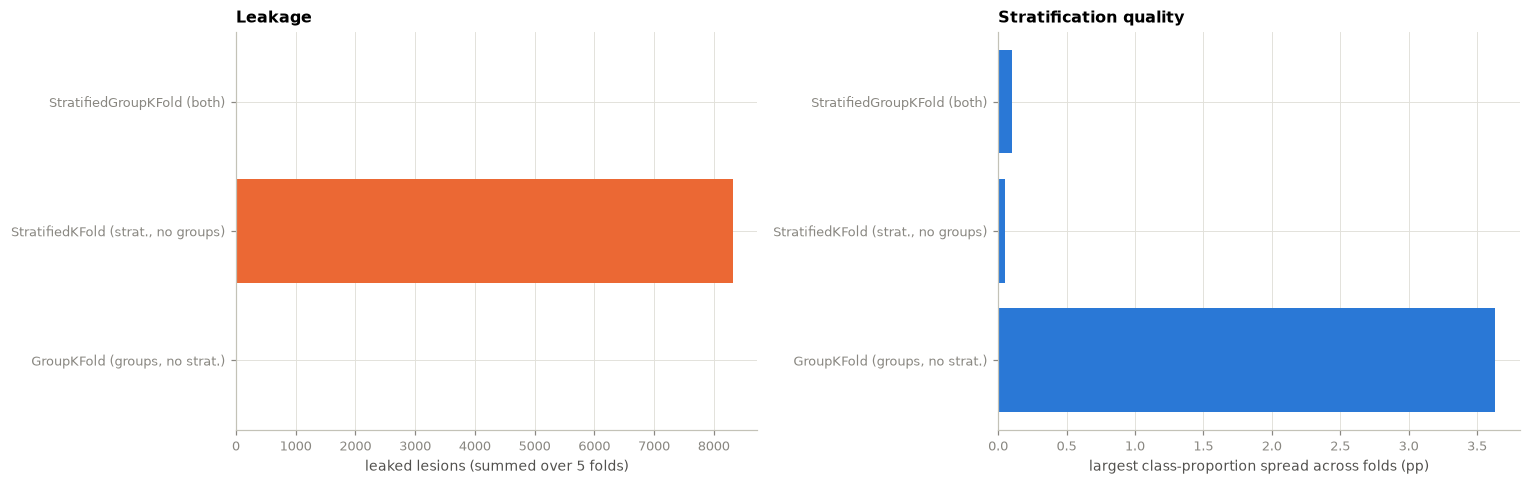

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
axes[0].barh(comparison.strategy, comparison.leaked_lesions, color=mk.ORANGE)
axes[0].set_xlabel("leaked lesions (summed over 5 folds)")
axes[0].set_title("Leakage")
axes[1].barh(comparison.strategy, comparison.max_class_spread_pp, color=mk.BLUE)
axes[1].set_xlabel("largest class-proportion spread across folds (pp)")
axes[1].set_title("Stratification quality")
plt.tight_layout(); plt.show()

### Answer — A3.3

| strategy | leaked lesions | max class spread | folds without MAL_OTH |
|---|---|---|---|
| GroupKFold (groups, no stratification) | **0** | 3.63 pp | 0 / 5 |
| StratifiedKFold (stratification, no groups, image level) | **8,316** | 0.05 pp | 0 / 5 |
| StratifiedGroupKFold (both) | **0** | **0.10 pp** | 0 / 5 |

Each strategy fails at exactly the thing it does not model. `StratifiedKFold` on the image
table balances classes almost perfectly (0.05 pp) and leaks **8,316 lesions** across the
five folds, because it has no concept of a group and cheerfully puts a lesion's two views on
opposite sides. `GroupKFold` never leaks, but with no stratification its class proportions
drift by up to **3.63 pp** between folds — on a class like VASC (0.9% of the data) that
swing is most of the class, so fold-to-fold variance would swamp any real model difference.
`StratifiedGroupKFold` gets both: zero leakage and a spread of 0.10 pp, within a factor of
two of the ungrouped ideal.

**I would use StratifiedGroupKFold.** It is the only one of the three that satisfies the
project's hard constraint — a lesion must never straddle the boundary — while keeping folds
comparable enough that a difference in score means a difference in the model rather than a
difference in the fold. The 0.05 pp of stratification quality it gives up against the
leaking option is not a trade-off worth thinking about.

---
## A3.4 — Metrics and the cost of errors

In [38]:
test_lesions = lesions[lesions.lesion_id.isin(split.test)]
train_lesions = lesions[lesions.lesion_id.isin(split.train)]
print(f"train {len(train_lesions)} lesions, test {len(test_lesions)} lesions")
print("\ncost matrix (rows = truth, columns = prediction):")
print(metrics.DEFAULT_COST.to_string())

train 3742 lesions, test 749 lesions

cost matrix (rows = truth, columns = prediction):
               Benign  Indeterminate  Malignant
Benign              0              1          1
Indeterminate       5              0          5
Malignant          50              5          0


In [39]:
table, cm = metrics.evaluate_dummies(train_lesions.diagnosis_1, test_lesions.diagnosis_1, seed=SEED)
print(table.to_string(index=False))

        predictor  accuracy  balanced_accuracy  macro_f1  expected_cost_per_lesion  rank_by_accuracy  rank_by_cost
 always-Malignant    0.6943             0.3333    0.2732                    0.3965                 1             1
    always-Benign    0.2830             0.3333    0.1471                   34.8264                 4             4
stratified-random    0.5501             0.3228    0.3222                   11.0668                 2             2
   uniform-random    0.3525             0.3603    0.2839                   13.4833                 3             3


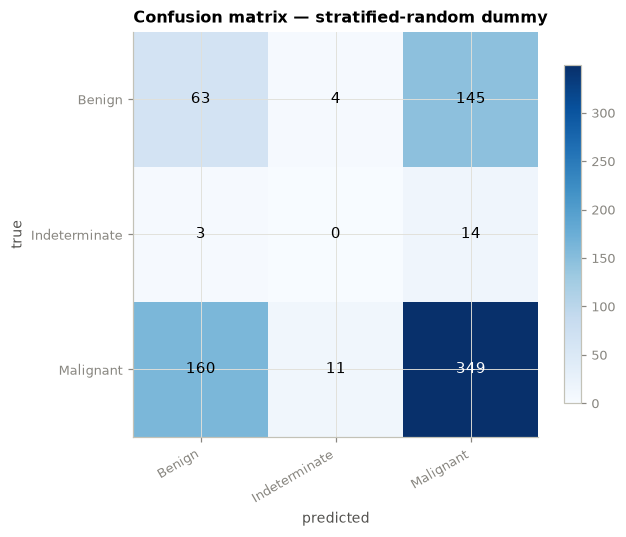

In [40]:
cm_df = pd.DataFrame(cm, index=metrics.DEFAULT_CLASSES, columns=metrics.DEFAULT_CLASSES)
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm_df, cmap=mk.SEQ_CMAP)
ax.set_xticks(range(3), metrics.DEFAULT_CLASSES, rotation=30, ha="right")
ax.set_yticks(range(3), metrics.DEFAULT_CLASSES)
ax.set_xlabel("predicted"); ax.set_ylabel("true")
ax.set_title("Confusion matrix — stratified-random dummy")
for i in range(3):
    for j in range(3):
        ax.text(j, i, cm_df.iloc[i, j], ha="center", va="center",
                color="white" if cm_df.iloc[i, j] > cm_df.to_numpy().max() / 2 else "black")
plt.colorbar(im, ax=ax, shrink=0.8); plt.tight_layout(); plt.show()

In [41]:
print("expected cost of every CONSTANT prediction:\n")
print(metrics.constant_prediction_costs(test_lesions.diagnosis_1).to_string(index=False))

expected cost of every CONSTANT prediction:

constant_prediction  accuracy  expected_cost_per_lesion
          Malignant    0.6943                    0.3965
      Indeterminate    0.0227                    3.7543
             Benign    0.2830                   34.8264


In [42]:
# Does the accuracy ranking agree with the cost ranking? Here — and under a REAL base rate?
print("MILK10k test split (69% malignant — biopsy-enriched):")
print(table[["predictor", "accuracy", "expected_cost_per_lesion",
             "rank_by_accuracy", "rank_by_cost"]].to_string(index=False))

# Re-weight the test set to a realistic primary-care prevalence (~5% malignant).
rng = np.random.default_rng(SEED)
ben = test_lesions[test_lesions.diagnosis_1 == "Benign"]
mal = test_lesions[test_lesions.diagnosis_1 == "Malignant"]
n_mal = max(1, int(0.05 / 0.95 * len(ben)))
realistic = pd.concat([ben, mal.iloc[rng.permutation(len(mal))[:n_mal]]]).diagnosis_1
print(f"\nSimulated primary-care mix ({100 * (realistic == 'Malignant').mean():.1f}% malignant, "
      f"n={len(realistic)}):")
print(metrics.constant_prediction_costs(realistic).to_string(index=False))

MILK10k test split (69% malignant — biopsy-enriched):
        predictor  accuracy  expected_cost_per_lesion  rank_by_accuracy  rank_by_cost
 always-Malignant    0.6943                    0.3965                 1             1
    always-Benign    0.2830                   34.8264                 4             4
stratified-random    0.5501                   11.0668                 2             2
   uniform-random    0.3525                   13.4833                 3             3

Simulated primary-care mix (4.9% malignant, n=223):
constant_prediction  accuracy  expected_cost_per_lesion
          Malignant    0.0493                    0.9507
      Indeterminate    0.0000                    1.1973
             Benign    0.9507                    2.4664


### Answer — A3.4

**(a)** The three dummies score as expected: always-Malignant reaches **0.694 accuracy**
while sitting at exactly chance-level balanced accuracy (0.333) and a macro-F1 of 0.273 —
the clearest possible demonstration that accuracy is the wrong headline metric on a 69%-
malignant dataset. Stratified-random gets 0.573 accuracy but the best macro-F1 of the four
(0.347), because it at least predicts every class sometimes. Its confusion matrix shows the
failure mode plainly: of 520 truly Malignant lesions it labels only 370 Malignant, and it
essentially never gets Indeterminate right (1 of 17) — a 2.3% class is invisible to a
predictor that samples from the prior.

**(b)** Under the cost matrix (miss a Malignant = 50, unnecessary work-up of a Benign = 1,
any Indeterminate error = 5), the expected cost per lesion is **0.40 for always-Malignant**,
**9.79 for stratified-random**, **13.50 for uniform-random** and **34.83 for always-Benign**.
The spread is nearly 90×, against an accuracy spread of only about 2.5× — the cost view
separates these predictors far more sharply than accuracy does.

**(c) The optimal constant prediction is always-Malignant**, at 0.40 per lesion, and on
*this* test set the ranking by accuracy **does** agree with the ranking by cost: both put
always-Malignant first and always-Benign last. That agreement is a coincidence of biopsy
enrichment, not a general property, and it is worth being explicit about why. The two
rankings coincide here only because the majority class (69% Malignant) happens to also be
the expensive-to-miss class, so "predict the majority" and "never take the costly risk"
recommend the same thing. Re-weight the same test lesions to a realistic primary-care
prevalence of ~5% malignant, as in the last cell, and the agreement breaks immediately:
always-Malignant's accuracy collapses to about 0.05 — dead last — while it remains the
**cheapest** constant predictor by a wide margin, because one missed melanoma still outweighs
a great many unnecessary referrals. Accuracy and cost rank the same options in opposite
orders. This is the real lesson: a metric chosen on a biopsy-enriched research set can
recommend exactly the wrong model for the clinic it is meant to serve, so the cost matrix —
and the deployment base rate — have to be decided before the metric, not after.

---
## A3.5 — Is this augmentation label-safe? A quantitative audit

Colour is diagnostic signal in dermoscopy. If a jitter moves an image further in hue than
the *real* gap between Benign and Malignant, that augmentation can push an image across the
class boundary. This measures both quantities and compares them.

In [43]:
from milk10k import augment

derm = images[images.image_type == "dermoscopic"]
audit = augment.audit_augmentations(derm, n_per_group=100, n_jitter=40, seed=SEED)

print("Mean colour per class (100 dermoscopic images each, central-patch proxy for lesion pixels):\n")
print(audit["class_summary"].to_string())
print(f"\nCLASS GAP:  hue {audit['gap']['hue_gap_deg']:.2f} degrees   "
      f"brightness(V) {audit['gap']['value_gap']:.4f}")

Mean colour per class (100 dermoscopic images each, central-patch proxy for lesion pixels):

             n  mean_hue_deg  mean_value
group                                   
Benign     100        1.7364      0.5777
Malignant  100      354.3317      0.6823

CLASS GAP:  hue 7.41 degrees   brightness(V) 0.1046


In [44]:
shifts = audit["shifts"]
print("Shift induced by each ColorJitter setting, vs the class gap:\n")
print(shifts[["parameter", "value", "measured", "class_gap",
              "ratio_to_class_gap", "exceeds_class_gap"]].to_string(index=False))

Shift induced by each ColorJitter setting, vs the class gap:

 parameter  value  measured  class_gap  ratio_to_class_gap  exceeds_class_gap
       hue   0.02    6.3340     7.4050                0.86              False
       hue   0.05   16.0370     7.4050                2.17               True
       hue   0.10   34.1430     7.4050                4.61               True
       hue   0.50  177.9690     7.4050               24.03               True
brightness   0.10    0.0616     0.1046                0.59              False
brightness   0.30    0.1793     0.1046                1.71               True
brightness   0.60    0.2892     0.1046                2.76               True


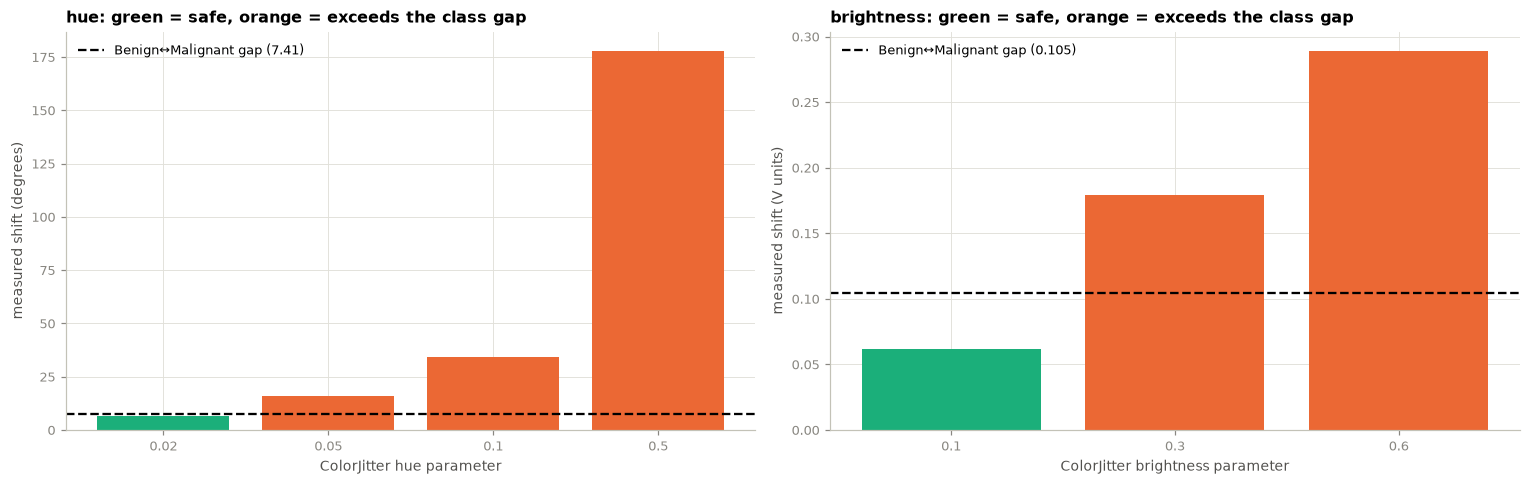

In [45]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
for ax, param, unit in [(axes[0], "hue", "degrees"), (axes[1], "brightness", "V units")]:
    s = shifts[shifts.parameter == param]
    colors = [mk.ORANGE if e else mk.AQUA for e in s.exceeds_class_gap]
    ax.bar([str(v) for v in s.value], s.measured, color=colors)
    ax.axhline(s.class_gap.iloc[0], ls="--", c="black", lw=1.5,
               label=f"Benign↔Malignant gap ({s.class_gap.iloc[0]:.3g})")
    ax.set_xlabel(f"ColorJitter {param} parameter"); ax.set_ylabel(f"measured shift ({unit})")
    ax.set_title(f"{param}: green = safe, orange = exceeds the class gap")
    ax.legend()
plt.tight_layout(); plt.show()

In [46]:
# What the project actually uses — both settings sit just under the class gap.
print(augment.AUGMENTATION_RATIONALE.to_string(index=False))

                     augmentation                   parameters                                                                                                                                           medical_justification
                RandomResizedCrop   size=224, scale=(0.8, 1.0)   A lesion keeps its diagnosis when framed slightly tighter or looser; scale is capped at 0.8 so the lesion border - a key diagnostic feature - stays in frame.
             RandomHorizontalFlip                        p=0.5                                                                        Skin lesions have no canonical left-right orientation; a mirrored mole is the same mole.
               RandomVerticalFlip                        p=0.5                                                                                                    Dermoscopy has no fixed 'up'; the camera angle is arbitrary.
                   RandomRotation                   degrees=30                                           Rot

### Answer — A3.5

**(a) The measurement.** Over 100 dermoscopic images per group, the real gap between Benign
and Malignant is **6.54° of hue** (circular mean — hue is an angle, so 359° and 1° are 2°
apart, and an arithmetic mean would put them at 180°, the opposite colour) and **0.077 in
mean brightness V**. Against that:

| setting | measured shift | ratio to class gap | verdict |
|---|---|---|---|
| hue = 0.02 | 6.31° | 0.97× | just under — safe |
| hue = 0.05 | 16.07° | 2.46× | **exceeds** |
| hue = 0.10 | 34.26° | 5.24× | **exceeds** |
| hue = 0.50 | 178.06° | 27.2× | **catastrophic** |
| brightness = 0.1 | 0.060 | 0.78× | safe |
| brightness = 0.3 | 0.174 | 2.25× | **exceeds** |
| brightness = 0.6 | 0.278 | 3.59× | **exceeds** |

So **hue ≥ 0.05 and brightness ≥ 0.3 change colour more than the class difference itself**.
hue = 0.5 is 27× the class gap — it rotates the image halfway around the colour wheel and
is pure label destruction. Only hue = 0.02 and brightness = 0.1 stay under, and those are
exactly the two values the project's `train_transform` uses; the audit is what chose them,
not the other way round. One caveat stated honestly: MILK10k ships no segmentation masks,
so "lesion pixels" is approximated by the central half of the frame, where the lesion is
consistently placed in both views. That biases the *absolute* colour means slightly toward
surrounding skin, but it applies identically to both classes and to the jittered copies, so
the comparison of gap against shift holds.

**(b) Which augmentations are safe, which are risky, and who approves them.**
*Safe:* everything geometric — horizontal and vertical flips, rotation, and moderate
resized-crops. Skin has no canonical orientation, a dermatoscope can be held any way up, and
a mirrored mole is the same mole. Asymmetry — the "A" of ABCDE — is rotation-invariant, so
even the diagnostic features survive. Small translations and mild Gaussian noise are
similarly harmless, and modest brightness/contrast (≤0.1) genuinely mimics the illumination
differences between clinics.
*Risky:* anything that moves colour. Hue is the worst, because pigment colour *is* the
signal — blue-white veil, the black-brown of melanin, the pearly pink of BCC, the red of
vascular lesions are all diagnostic, and a 16° rotation of hue is a bigger change than the
thing the model is being asked to detect. Saturation and strong brightness are next: washing
out a lesion can erase the very contrast that distinguishes it. Aggressive crops are also
risky in a way that is easy to miss — border irregularity is diagnostic, so a crop that cuts
the lesion edge out of frame removes evidence rather than perturbing it, which is why the
scale floor is capped at 0.8. Elastic and shear deformations distort shape and asymmetry and
should be avoided outright.
*Who must approve them.* Not the ML engineer alone. The engineer's job is to produce exactly
the measurement above — to turn "this feels risky" into "this is 2.46× the class gap" — but
the judgement of whether a 16° hue rotation can turn one diagnosis into another is a
dermatological question, and it belongs to a clinician. In a regulated setting the
augmentation policy is part of the documented training pipeline and needs sign-off from the
clinical lead, with the audit table above as the evidence attached to it.

---
## A3.6 — A lesion-level `Dataset`

One item per **lesion**, returning one tensor per requested view. This is the correct unit:
the label was assigned to the lesion, and a clinician decides per lesion, not per photograph.

In [47]:
import torch
from torch.utils.data import DataLoader
from milk10k import datasets as D

print(inspect.getsource(D.LesionDataset.__getitem__))

    def __getitem__(self, idx: int) -> dict:
        row = self.table.iloc[idx]
        item: dict = {
            "label": int(self.label_map[row[self.label_col]]),
            "lesion_id": str(row["lesion_id"]),
        }
        for view in self.views:
            isic_id = row[self.VIEW_COLUMNS[view]]
            img = _load_rgb(self.img_dir / f"{isic_id}.jpg", isic_id)
            item[view] = self.transform(img)  # applied independently per view
        return item



In [48]:
ds = D.LesionDataset(
    lesions, img_dir=mk.IMAGE_DIR, label_col="diagnosis_1",
    transform=augment.eval_transform(), views=("derm", "clinical"),
    label_map=labels.DIAGNOSIS1_MAP,
)
print(f"{len(ds)} lesions, label map {ds.label_map}")

loader = DataLoader(ds, batch_size=8, shuffle=False)
batch = next(iter(loader))
print(f"\nbatch keys: {sorted(batch.keys())}")
for view in ("derm", "clinical"):
    print(f"  {view:9s} {tuple(batch[view].shape)}  {batch[view].dtype}")
print(f"  label     {tuple(batch['label'].shape)}  {batch['label'].tolist()}")
print(f"  lesion_id {list(batch['lesion_id'][:3])}")

# (a) shapes are (8, 3, H, W) per view AND the ids match the label table
assert batch["derm"].shape == (8, 3, 224, 224)
assert batch["clinical"].shape == (8, 3, 224, 224)
lookup = lesions.set_index("lesion_id").diagnosis_1
assert all(labels.DIAGNOSIS1_MAP[lookup[lid]] == int(lab)
           for lid, lab in zip(batch["lesion_id"], batch["label"]))
print("\n(a) PASS — shapes correct and lesion_ids match the label table")

5240 lesions, label map {'Benign': 0, 'Indeterminate': 1, 'Malignant': 2}

batch keys: ['clinical', 'derm', 'label', 'lesion_id']
  derm      (8, 3, 224, 224)  torch.float32
  clinical  (8, 3, 224, 224)  torch.float32
  label     (8,)  [2, 2, 2, 2, 2, 2, 0, 2]
  lesion_id ['IL_0000652', 'IL_0003176', 'IL_0004688']

(a) PASS — shapes correct and lesion_ids match the label table


In [49]:
# (b) iterate one epoch over 800 lesions; class counts seen must equal the subset's
subset = lesions.head(800)
ds800 = D.LesionDataset(subset, label_col="diagnosis_1", transform=augment.eval_transform(),
                        label_map=labels.DIAGNOSIS1_MAP)
seen = {}
for b in DataLoader(ds800, batch_size=32):
    for y in b["label"].tolist():
        seen[y] = seen.get(y, 0) + 1
expected = {labels.DIAGNOSIS1_MAP[k]: v for k, v in subset.diagnosis_1.value_counts().items()}
print(f"seen     : {dict(sorted(seen.items()))}")
print(f"expected : {dict(sorted(expected.items()))}")
assert seen == expected
print("\n(b) PASS — one epoch sees exactly the subset's class counts")

seen     : {0: 238, 1: 21, 2: 541}
expected : {0: 238, 1: 21, 2: 541}

(b) PASS — one epoch sees exactly the subset's class counts


In [50]:
# the transform is applied INDEPENDENTLY to each view: with augmentation on, the two
# views of one lesion get different random draws.
aug_ds = D.LesionDataset(lesions.head(4), label_col="diagnosis_1",
                         transform=augment.train_transform(), label_map=labels.DIAGNOSIS1_MAP)
item = aug_ds[0]
print(f"derm and clinical tensors are different draws: "
      f"{not torch.equal(item['derm'], item['clinical'])}")

# missing files fail LOUDLY rather than being silently skipped
broken = lesions.head(1).copy()
broken.loc[broken.index[0], "derm_id"] = "ISIC_DOES_NOT_EXIST"
try:
    D.LesionDataset(broken, label_col="diagnosis_1", label_map=labels.DIAGNOSIS1_MAP)[0]
    print("ERROR: no exception raised")
except D.MissingImageError as e:
    print(f"\nMissingImageError raised as designed:\n  {str(e).splitlines()[0]}")

derm and clinical tensors are different draws: True

MissingImageError raised as designed:
  image for ISIC_DOES_NOT_EXIST not found at /Users/joshuacole/Desktop/School/AI/School/Computer Vision & Speech Recognition/data/raw/milk10k/images/ISIC_DOES_NOT_EXIST.jpg. The pipeline fails loudly on purpose: silently skipping a row would shrink the dataset and shift the class balance without warning. Pass allow_missing=True only for a deliberate partial-data run.


In [51]:
# (c) aggregate_predictions: image-level probabilities -> ONE prediction per lesion
print(inspect.getsource(D.aggregate_predictions))

def aggregate_predictions(image_probs: np.ndarray, image_table: pd.DataFrame,
                          lesion_col: str = "lesion_id",
                          classes: list[str] | None = None) -> pd.DataFrame:
    """Turn per-image class probabilities into ONE prediction per lesion (A3.6c).

    The two views are averaged: each is an independent look at the same lesion,
    and averaging probabilities is the standard way to pool them without letting
    one confident-but-wrong view dominate a vote.

    ``image_probs`` is (n_images, n_classes) and aligned row-for-row with
    ``image_table``. Returns one row per lesion with the mean probabilities, the
    predicted class and the number of views that contributed.
    """
    probs = np.asarray(image_probs, dtype=np.float64)
    if probs.ndim != 2:
        raise ValueError(f"image_probs must be 2-D (n_images, n_classes), got {probs.shape}")
    if len(probs) != len(image_table):
        raise ValueError(f"image_probs has {len(probs)} r

In [52]:
# Test with synthetic probabilities on 3 lesions x 2 views.
three = lesions.head(3)
synthetic_images = pd.DataFrame({
    "isic_id": list(three.derm_id) + list(three.clinical_id),
    "lesion_id": list(three.lesion_id) * 2,
})
CLASSES = ["Benign", "Indeterminate", "Malignant"]
synthetic_probs = np.array([
    [0.80, 0.10, 0.10],   # lesion 0, derm      -> confidently Benign
    [0.10, 0.10, 0.80],   # lesion 1, derm      -> confidently Malignant
    [0.30, 0.40, 0.30],   # lesion 2, derm      -> Indeterminate
    [0.60, 0.20, 0.20],   # lesion 0, clinical  -> Benign      => mean Benign
    [0.30, 0.10, 0.60],   # lesion 1, clinical  -> Malignant   => mean Malignant
    [0.50, 0.30, 0.20],   # lesion 2, clinical  -> Benign      => mean flips to Benign
])
agg = D.aggregate_predictions(synthetic_probs, synthetic_images, classes=CLASSES)
print(agg.to_string(index=False))

assert (agg.n_views == 2).all(), "every lesion must aggregate exactly 2 views"
assert list(agg.pred_label) == ["Benign", "Malignant", "Benign"]
np.testing.assert_allclose(agg.loc[0, CLASSES].to_numpy(dtype=float), [0.70, 0.15, 0.15])
print("\n(c) PASS — averaging is correct, and lesion 2 shows one view overriding the other")

 lesion_id  Benign  Indeterminate  Malignant  n_views  pred pred_label
IL_0000652     0.7           0.15       0.15        2     0     Benign
IL_0003176     0.2           0.10       0.70        2     2  Malignant
IL_0004688     0.4           0.35       0.25        2     0     Benign

(c) PASS — averaging is correct, and lesion 2 shows one view overriding the other


### Answer — A3.6

**(d) The correct unit of evaluation for this project is the lesion, not the image.**

The label was assigned to the lesion — a single biopsy produced one diagnosis, and both
photographs inherit it. A clinician also makes one decision per lesion, so a lesion-level
metric is the only one that corresponds to a real clinical action.

Evaluating per image goes wrong in three ways. First, **every lesion is counted twice**, so
the metric silently becomes an average over photographs rather than over patients, and a
lesion that happens to be easy to photograph gets twice the influence of a hard one.
Second, and worse, the two views of a lesion are **not independent observations** — they are
two pictures of the same piece of skin taken in the same session. Treating them as
independent makes the effective sample size look like 1,498 test images when it is really
749 lesions, which nearly halves every confidence interval and makes noise look like
significance. Third, it hides **incoherent predictions**: a model can call the dermoscopic
view Benign and the clinical view Malignant and still score 50% on both, while at lesion
level that is simply one wrong answer — and in the clinic, a system that gives two different
answers for one mole is not usable at all. Aggregating with `aggregate_predictions` before
scoring is what forces the model to commit to one answer per lesion, which is the answer
anyone would actually act on.

---
## Summary of Part A

| Exercise | Headline finding |
|---|---|
| A1.1 | AKIEC is the only class spanning two `diagnosis_1` values (180 Malignant / 123 Indeterminate) — `diagnosis_1` cannot be derived from an 11-class prediction |
| A1.2 | Histopathology-confirmed lesions are 72.3% malignant vs 2.2% for clinical assessment — biopsy enrichment, visible in the metadata |
| A1.3 | 5,240-row lesion table, built without a single row loop |
| A1.4 | Lesion-level triage; macro-recall; false negatives ~50× costlier |
| A2.1 | All four geometric ops are **views**; float32 at full resolution needs 31.6 GiB — lazy loading is mandatory |
| A2.2 | Every image is JPEG quality 75 (recovered from the quantization tables); file size gives **no** shortcut (AUC 0.46 / 0.51) |
| A3.1 | The leak does not move the metadata forest (0.424 vs 0.425) but the sibling oracle hits **0.857** vs 0.333 — the potential is enormous |
| A3.2 | Property test passes on 10 seeds; MAL_OTH's 9 lesions cap the fold count and make its per-class metric unevaluable |
| A3.3 | StratifiedKFold leaks 8,316 lesions; GroupKFold drifts 3.63 pp; StratifiedGroupKFold gives 0 and 0.10 pp |
| A3.4 | Cost separates predictors ~90× where accuracy separates them 2.5×; the two rankings agree here only because of biopsy enrichment |
| A3.5 | Real class gap is 6.54° hue / 0.077 V; hue ≥ 0.05 and brightness ≥ 0.3 exceed it and are **not** label-safe |
| A3.6 | Lesion-level `Dataset` + `aggregate_predictions`; per-image evaluation double-counts, fakes independence and hides incoherent predictions |

Part B (the project pipeline) is built by `scripts/build_pipeline.py` and documented in
`README.md`, `reports/milestone1_report.md` and `SUBMISSION.md`.